# Iskanje podatkov PlanetScope in ustvarjanje naročila

Poiščimo satelitske posnetke izbranega območja in ustvarimo naročilo. Naročilo shranimo v zbirko (collection) in ga pošljemo v obdelavo.

## Zahteve

- nameščen Python
- knjižnica requests
- [Planet Account](https://www.planet.com/account/#/)
- API ključ za dostop do Planet API

In [1]:
# Potrebne knjižnice
import os
import json
import math
import requests
from typing import Dict, List, Iterator
# Kartiranje AOI iz GeoJSON datoteke
import contextily as ctx
import matplotlib.pyplot as plt
from shapely.geometry import shape

## Nastavitev API ključa

Najprej moramo nastaviti naš API ključ, da bomo lahko dostopali do Planet API. To lahko storimo tako, da ga shranimo kot spremenljivko okolja ali pa ga neposredno uporabimo v našem Python skriptu.

In [2]:
# Če vaš Planet API ključ ni nastavljen kot spremenljivka okolja, ga lahko prilepite spodaj
if os.environ.get('PL_API_KEY', ''):
    API_KEY = os.environ.get('PL_API_KEY', '')
else:
    API_KEY = 'PASTE_YOUR_API_KEY_HERE'

In [3]:
# Izpiši API ključ za preverjanje pravilnega nalaganja (neobvezno)
print(f'API ključ naložen: {API_KEY[:4]}...{API_KEY[-4:]}')

API ključ naložen: PLAK...fdbd


## Določitev območja interesa

Območje interesa (**Area of Interest** ali *AOI*) določa geografsko območje, iz katerega želimo pridobiti podatke.

Pri Data API je to lahko preprost pravokotnik (bounding box) s štirimi vogali ali bolj kompleksna oblika, dokler je definicija zapisana v formatu [GeoJSON](http://geojson.org/).

V tem primeru bomo uporabili preprost pravokotnik. Za enostavno ustvarjanje lahko uporabimo [geojson.io](http://geojson.io/), kjer hitro narišemo obliko in dobimo GeoJSON zapis:

![geojsonio.png](./slike/geojsonio.png)

Za zahtevo Data API potrebujemo samo objekt **geometry**, ki ga lahko preberemo iz GeoJSON datoteke. Ta objekt vsebuje koordinate, ki definirajo naše AOI. Na primer, če imamo GeoJSON datoteko z imenom `aoi.geojson`, lahko preberemo geometrijo.

In [4]:
# Ime datoteke z AOI
aoi_file = './podatki/kranj_aoi.geojson'
with open(aoi_file) as f:
    geojson_data = json.load(f)
geojson_geometry = geojson_data['features'][0]['geometry']

In [5]:
# Izpis geometrije AOI, da preverite, ali je pravilno prebrana
print(json.dumps(geojson_geometry, indent=2, ensure_ascii=False))

{
  "coordinates": [
    [
      [
        14.338274979185115,
        46.234310509304606
      ],
      [
        14.384337227889091,
        46.234310509304606
      ],
      [
        14.384337227889091,
        46.262948793445105
      ],
      [
        14.338274979185115,
        46.262948793445105
      ],
      [
        14.338274979185115,
        46.234310509304606
      ]
    ]
  ],
  "type": "Polygon"
}


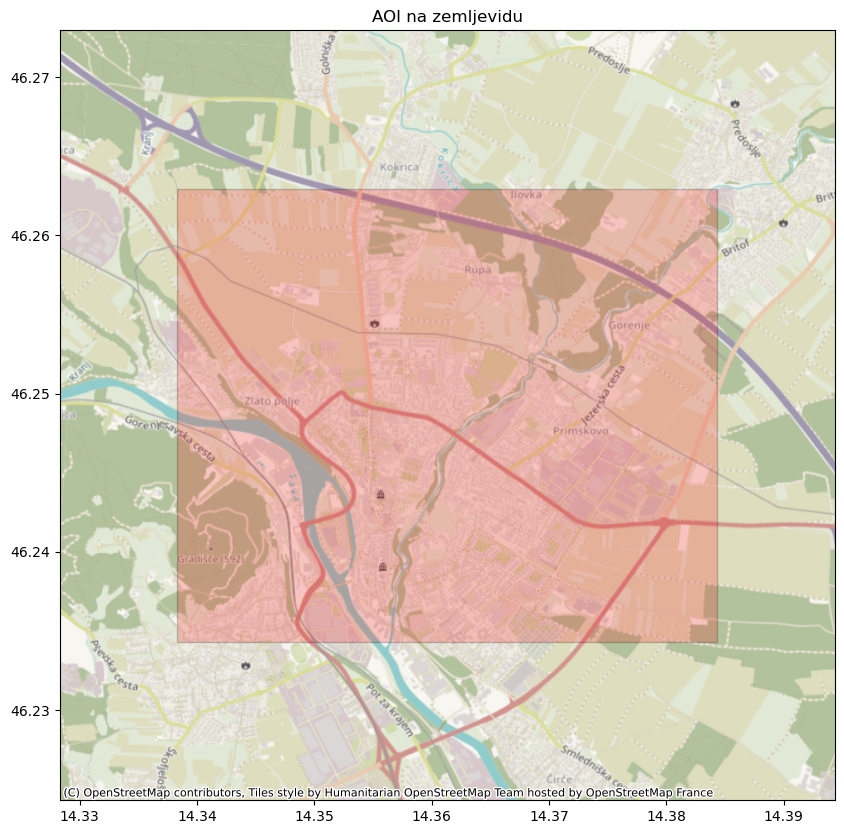

In [6]:
# Prikaz geometrije AOI na ozadju zemljevida, uporabi contextily
aoi_shape = shape(geojson_geometry)
# Pridobitev koordinatnih omejitev AOI
minx, miny, maxx, maxy = aoi_shape.bounds
# Prikaz AOI na zemljevidu
fig, ax = plt.subplots(figsize=(10, 10))
# Prikaz AOI kot rdečega poligona
x, y = aoi_shape.exterior.xy
ax.fill(x, y, alpha=0.2, fc='red', ec='black')
# Nastavitev omejitev zemljevida na AOI 
ax.set_xlim(minx - 0.01, maxx + 0.01)
ax.set_ylim(miny - 0.01, maxy + 0.01)
# Dodajanje ozadja zemljevida
ctx.add_basemap(ax, crs='EPSG:4326')
ax.set_title('AOI na zemljevidu')
plt.show()

## Nastavitve

In [7]:
# Nastavitve iskanja in naročila
ORDER_NAME = "Kranj" # Poimenujte naročilo po želji
ITEM_TYPE = "PSScene"
PRODUCT_BUNDLE = "ortho_analytic_8b_sr" # spremeni, če tvoja konfiguracija zahteva drug produktni paket
START_DATE = "2023-01-01T00:00:00Z"
END_DATE = "2025-12-31T23:59:59Z"
MAX_CLOUD_COVER = 0.10 # 10% - maksimalna pokritost oblačnosti
AREA_COVERAGE = 0.80 # 80% - minimalna pokritost površine
CLIP_TO_AOI = False # Rezanje posnetkov na AOI (privzeto False)
BATCH_SIZE = 500 # API za naročila podpira do 500 artiklov na naročilo
TARGET_COLLECTION_ID = None # Nastavi na obstoječi ID kolekcije za dodajanje v isto kolekcijo; sicer None

In [8]:
# API endpointa za iskanje posnetkov in ustvarjanje naročil
DATA_SEARCH_URL = "https://api.planet.com/data/v1/quick-search"
ORDERS_URL = "https://api.planet.com/compute/ops/orders/v2"

### API povezave in avtentikacija

V tej sekciji določimo URL-je storitev in inicializiramo HTTP sejo z API ključem.

In [9]:
# Inicializacija HTTP seje in avtentikacije za vse API klice
SESSION = requests.Session()
SESSION.headers.update({"Content-Type": "application/json"})
SESSION.auth = (API_KEY, "")

## Pomožne funkcije

Funkcije spodaj pripravijo filter iskanja, izvajajo straničeno branje rezultatov in ustvarijo naročila.

In [10]:
# Sestava kombiniranega filtra za AOI, časovno obdobje, oblačnost in pokritost površine
def build_search_filter(aoi: Dict, start_date: str, end_date: str, max_cloud: float, min_area_coverage: float) -> Dict:
    # Sestavimo kombinirani filter: geometrija + datum + oblačnost + minimalna pokritost površine.
    return {
        "type": "AndFilter",
        "config": [
            {
                "type": "GeometryFilter",
                "field_name": "geometry",
                "config": aoi
            },
            {
                "type": "DateRangeFilter",
                "field_name": "acquired",
                "config": {
                    "gte": start_date,
                    "lte": end_date
                }
            },
            {
                "type": "RangeFilter",
                "field_name": "cloud_cover",
                "config": {
                    "lte": max_cloud
                }
            },
            {
                "type": "RangeFilter",
                "field_name": "visible_percent",
                "config": {
                    "gte": min_area_coverage
                }
            }
        ]
    }

In [11]:
# Iskanje posnetkov preko Quick Search API z avtomatskim prehajanjem po straneh
def search_items(item_type: str, search_filter: Dict, page_size: int = 250) -> Iterator[Dict]:
    body = {
        "item_types": [item_type],
        "filter": search_filter
    }

    # Začetni klic z naraščajočim časovnim vrstnim redom.
    url = f"{DATA_SEARCH_URL}?_sort=acquired%20asc&_page_size={page_size}"
    resp = SESSION.post(url, json=body)
    resp.raise_for_status()
    data = resp.json()

    # Iteriramo čez vse strani rezultatov, dokler API vrača _next povezavo.
    while True:
        for feature in data.get("features", []):
            yield feature

        next_url = data.get("_links", {}).get("_next")
        if not next_url:
            break

        next_resp = SESSION.get(next_url)
        next_resp.raise_for_status()
        data = next_resp.json()

In [12]:
# Razdeli seznam ID-jev na manjše pakete velikosti size
def chunked(seq: List[str], size: int) -> Iterator[List[str]]:
    for i in range(0, len(seq), size):
        yield seq[i:i + size]

In [13]:
# Ustvarjanje gostovanega naročila in vračilo API odziva
def create_hosted_order(
    order_name: str,
    item_ids: List[str],
    item_type: str,
    product_bundle: str,
    clip_to_aoi: bool = False,
    aoi_geometry: Dict | None = None,
    target_collection_id: str | None = None,
) -> Dict:
    # Nekateri navajajo ime sredstva (npr. ortho_analytic_8b_sr) namesto product_bundle.
    # Tu ga preslikamo na veljaven produktni paket za Orders API.
    bundle_aliases = {
        "ortho_analytic_8b_sr": "analytic_8b_sr_udm2",
    }
    resolved_bundle = bundle_aliases.get(product_bundle, product_bundle)
    if resolved_bundle != product_bundle:
        print(
            f"Info: produktni paket '{product_bundle}' je preslikan v '{resolved_bundle}' za Orders API."
        )

    # Če je podan collection_id, naročilo dodamo v obstoječo kolekcijo.
    # Sicer Planet ustvari novo kolekcijo.
    hosting_config = {
        "sentinel_hub": {
            "collection_id": target_collection_id
        }
    } if target_collection_id else {
        "sentinel_hub": {
            "create_configuration": True
        }
    }

    payload = {
        "name": order_name,
        "source_type": "scenes",
        "products": [
            {
                "item_ids": item_ids,
                "item_type": item_type,
                "product_bundle": resolved_bundle
            }
        ],
        "hosting": hosting_config
    }

    # Opcijsko rezanje na AOI: v Orders API gre clip v tools, ne v products.
    if clip_to_aoi:
        if aoi_geometry is None:
            raise ValueError("aoi_geometry je obvezen, ko je clip_to_aoi=True")
        payload["tools"] = [
            {
                "clip": {
                    "aoi": aoi_geometry
                }
            }
        ]

    resp = SESSION.post(ORDERS_URL, json=payload)
    if not resp.ok:
        # Dodamo koristno diagnostiko za 4xx/5xx odzive API-ja.
        raise requests.HTTPError(
            f"{resp.status_code} {resp.reason} | {resp.text}",
            response=resp,
        )
    return resp.json()

## Iskanje posnetkov

In [14]:
# Filter za iskanje
search_filter = build_search_filter(geojson_geometry, START_DATE, END_DATE, MAX_CLOUD_COVER, AREA_COVERAGE)

In [15]:
# Iskanje posnetkov v katalogu in priprava seznama ID-jev
print("Iščem Planet katalog...")
# Iz iskalnika preberemo vse najdene feature-je in izluščimo njihove ID-je.
features = list(search_items(ITEM_TYPE, search_filter))
item_ids = [f["id"] for f in features]
# Izpis skupnega števila najdenih posnetkov
print(f"Najdenih posnetkov: {len(item_ids)}")

Iščem Planet katalog...
Najdenih posnetkov: 516


In [16]:
# Natisni nekaj zadetkov
for f in features[:5]:
    props = f.get("properties", {})
    print(f"- {f['id']} | zajeto={props.get('acquired')} | oblačnost={props.get('cloud_cover')}")

- 20230111_093721_67_2475 | zajeto=2023-01-11T09:37:21.673736Z | oblačnost=0.01
- 20230114_093508_86_24a4 | zajeto=2023-01-14T09:35:08.860756Z | oblačnost=0.04
- 20230131_090120_93_241e | zajeto=2023-01-31T09:01:20.934613Z | oblačnost=0
- 20230201_093151_99_2475 | zajeto=2023-02-01T09:31:51.9964Z | oblačnost=0
- 20230202_085843_79_242d | zajeto=2023-02-02T08:58:43.795515Z | oblačnost=0.01


## Ustvarjanje naročil

Najdene posnetke razdelimo v pakete in za vsak paket ustvarimo ločeno naročilo.

In [17]:
# Izpiši povzetek naročila in parametrov iskanja
print("\nPovzetek naročila:")
print(f"- Ime naročila: {ORDER_NAME}")
print(f"- Tip posnetkov: {ITEM_TYPE}")
print(f"- Produktni paket: {PRODUCT_BUNDLE}")
print(f"- Datumski razpon: {START_DATE} do {END_DATE}")
print(f"- Največja oblačnost: {MAX_CLOUD_COVER * 100}%")
# Izpiši vrednosti parametrov iskanja
print(f"- Pokritost območja: {AREA_COVERAGE * 100}%")
print(f"- Obreži na AOI: {CLIP_TO_AOI}")
print(f"- Velikost paketa: {BATCH_SIZE}")
print(f"- Ciljni ID kolekcije: {TARGET_COLLECTION_ID}")
# AOI file in geometrija
print(f"- AOI datoteka: {aoi_file}")
print(f"- Tip geometrije AOI: {geojson_geometry['type']}")
# Izpiši število najdenih posnetkov, ki bodo naročeni
print(f"\nSkupno število posnetkov za naročilo: {len(item_ids)}")


Povzetek naročila:
- Ime naročila: Kranj
- Tip posnetkov: PSScene
- Produktni paket: ortho_analytic_8b_sr
- Datumski razpon: 2023-01-01T00:00:00Z do 2025-12-31T23:59:59Z
- Največja oblačnost: 10.0%
- Pokritost območja: 80.0%
- Obreži na AOI: False
- Velikost paketa: 500
- Ciljni ID kolekcije: None
- AOI datoteka: ./podatki/kranj_aoi.geojson
- Tip geometrije AOI: Polygon

Skupno število posnetkov za naročilo: 516


In [18]:
# Opozorilo: naslednji korak bo ustvaril naročilo in lahko povzroči stroške
print("\nOPOZORILO: Naslednji korak bo ustvaril gostovano naročilo v vašem Planet računu, kar lahko povzroči stroške glede na vaš naročniški paket. Prosimo, preverite seznam posnetkov zgoraj in potrdite, da želite nadaljevati.")
odgovor = input("Ali želite nadaljevati z ustvarjanjem naročila? (da/ne): ").strip().lower()
if odgovor not in ('da', 'yes'):
    print("Ustvarjanje naročila je preklical uporabnik.")
    proceed = False
else:
    proceed = True
    print("Ustvarjanje naročila se nadaljuje.")


OPOZORILO: Naslednji korak bo ustvaril gostovano naročilo v vašem Planet računu, kar lahko povzroči stroške glede na vaš naročniški paket. Prosimo, preverite seznam posnetkov zgoraj in potrdite, da želite nadaljevati.
Ustvarjanje naročila se nadaljuje.


In [19]:
# Ustvari eno ali več naročil po potrebi
orders = []
num_batches = math.ceil(len(item_ids) / BATCH_SIZE)

In [20]:
# To izvedemo le, če je uporabnik potrdil nadaljevanje
if proceed:
    # Če je podan TARGET_COLLECTION_ID, vsi batchi gredo v isto obstoječo kolekcijo.
    # Če ni podan, prvi batch ustvari novo kolekcijo, naslednji pa jo ponovno uporabijo.
    shared_collection_id = TARGET_COLLECTION_ID
    
    # Ustvarjanje enega ali več naročil glede na velikost batcha
    for idx, batch in enumerate(chunked(item_ids, BATCH_SIZE), start=1):
        # Če je rezultatov več kot BATCH_SIZE, jih razdelimo na več naročil.
        batch_name = f"{ORDER_NAME}-part-{idx:02d}-of-{num_batches:02d}" if num_batches > 1 else ORDER_NAME
        print(f"Ustvarjam naročilo: {batch_name} ({len(batch)} posnetkov)")
        order = create_hosted_order(
            batch_name,
            batch,
            ITEM_TYPE,
            PRODUCT_BUNDLE,
            clip_to_aoi=CLIP_TO_AOI,
            aoi_geometry=geojson_geometry,
            target_collection_id=shared_collection_id,
        )
        orders.append(order)

        order_id = order.get("id")
        state = order.get("state")
        collection_id = (
            order.get("hosting", {})
                    .get("sentinel_hub", {})
                    .get("collection_id")
        )

        if shared_collection_id is None and collection_id:
            shared_collection_id = collection_id
            print(f"  Uporabljam skupni ID kolekcije za naslednje batche: {shared_collection_id}")

        print(f"  ID naročila: {order_id}")
        print(f"  Stanje: {state}")
        print(f"  ID kolekcije: {collection_id}")
else:
    print("Naročila niso bila ustvarjena. Izhod.")

Ustvarjam naročilo: Kranj-part-01-of-02 (500 posnetkov)
Info: produktni paket 'ortho_analytic_8b_sr' je preslikan v 'analytic_8b_sr_udm2' za Orders API.
  Uporabljam skupni ID kolekcije za naslednje batche: 2286cc72-f23d-4f9c-9609-3f00b3d8e76c
  ID naročila: 6485f682-510e-406d-bb83-e9e5f8ca53d7
  Stanje: queued
  ID kolekcije: 2286cc72-f23d-4f9c-9609-3f00b3d8e76c
Ustvarjam naročilo: Kranj-part-02-of-02 (16 posnetkov)
Info: produktni paket 'ortho_analytic_8b_sr' je preslikan v 'analytic_8b_sr_udm2' za Orders API.
  ID naročila: d0da89fe-edd7-4d16-8baf-53fb47af2d54
  Stanje: queued
  ID kolekcije: 2286cc72-f23d-4f9c-9609-3f00b3d8e76c


## Povzetek rezultatov

Na koncu izpišemo vsa ustvarjena naročila in njihovo trenutno stanje.

In [21]:
# Končni izpis ustvarjenih naročil in njihovih stanj
print("\nKončano.")
print("Ustvarjena naročila:")
for order in orders:
    print(f"- {order.get('id')} | {order.get('name')} | {order.get('state')}")


Končano.
Ustvarjena naročila:
- 6485f682-510e-406d-bb83-e9e5f8ca53d7 | Kranj-part-01-of-02 | queued
- d0da89fe-edd7-4d16-8baf-53fb47af2d54 | Kranj-part-02-of-02 | queued
